Descàrrega de dades de Bitcoin i Or

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
btc = yf.download("BTC-USD", period="730d", interval="1h", auto_adjust=False)
gld = yf.download("GLD", period="730d", interval="1h", auto_adjust=False)

print("BTC shape:", btc.shape)
print("GLD shape:", gld.shape)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

BTC shape: (17358, 6)
GLD shape: (5077, 6)


Neteja de columnes multi índex

In [3]:
btc.columns = btc.columns.get_level_values(0)
gld.columns = gld.columns.get_level_values(0)

btc.head(), gld.head()

(Price                         Adj Close         Close          High  \
 Datetime                                                              
 2024-04-13 00:00:00+00:00  66902.976562  66902.976562  67147.718750   
 2024-04-13 01:00:00+00:00  65809.250000  65809.250000  66923.164062   
 2024-04-13 02:00:00+00:00  66500.890625  66500.890625  66557.476562   
 2024-04-13 03:00:00+00:00  67138.656250  67138.656250  67163.195312   
 2024-04-13 04:00:00+00:00  67583.296875  67583.296875  67886.718750   
 
 Price                               Low          Open      Volume  
 Datetime                                                           
 2024-04-13 00:00:00+00:00  66804.320312  67147.718750           0  
 2024-04-13 01:00:00+00:00  65809.250000  66923.164062  1360953344  
 2024-04-13 02:00:00+00:00  65898.859375  65898.859375   887877632  
 2024-04-13 03:00:00+00:00  66510.851562  66534.320312           0  
 2024-04-13 04:00:00+00:00  67046.390625  67156.968750   744259584  ,
 Price    

Verificació ràpida

In [4]:
print(btc.columns)
print(gld.columns)

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')
Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


Sincronització de dades de Bitcoin i Or.
Rang de dates coherent (Bitcoin funciona 24 hores, però l'or no).
Normalitzar timestamps a inici d'hora.
Renombrar columnes.

In [5]:
btc_1h = btc[["Close"]].copy()
gld_1h = gld[["Close"]].copy()

btc_1h.index = btc_1h.index.floor("1h")
gld_1h.index = gld_1h.index.floor("1h")

btc_1h.columns.name = None
gld_1h.columns.name = None

btc_1h = btc_1h.rename(columns={"Close": "btc_close"})
gld_1h = gld_1h.rename(columns={"Close": "gld_close"})

print(btc_1h.head())
print(gld_1h.head())

                              btc_close
Datetime                               
2024-04-13 00:00:00+00:00  66902.976562
2024-04-13 01:00:00+00:00  65809.250000
2024-04-13 02:00:00+00:00  66500.890625
2024-04-13 03:00:00+00:00  67138.656250
2024-04-13 04:00:00+00:00  67583.296875
                            gld_close
Datetime                             
2023-05-12 13:00:00+00:00  187.089996
2023-05-12 14:00:00+00:00  186.839996
2023-05-12 15:00:00+00:00  186.774994
2023-05-12 16:00:00+00:00  187.179993
2023-05-12 17:00:00+00:00  187.164993


Obtenir intersecció de dades

In [6]:
common_index = btc_1h.index.intersection(gld_1h.index)

btc_sync = btc_1h.loc[common_index].copy()
gld_sync = gld_1h.loc[common_index].copy()

print("BTC sync shape:", btc_sync.shape)
print("GLD sync shape:", gld_sync.shape)
print("Start:", common_index.min())
print("End:", common_index.max())

BTC sync shape: (3440, 1)
GLD sync shape: (3440, 1)
Start: 2024-04-15 13:00:00+00:00
End: 2026-04-10 19:00:00+00:00


Fusió de datasets de Bitcoin i Or

In [7]:
df = btc_sync.join(gld_sync, how="inner")

print("Merged shape:", df.shape)
df.head()

Merged shape: (3440, 2)


,btc_close,gld_close
Datetime,,
2024-04-15 13:00:00+00:00,65850.304688,215.940002
2024-04-15 14:00:00+00:00,64246.492188,217.658905
2024-04-15 15:00:00+00:00,64538.929688,217.404999
2024-04-15 16:00:00+00:00,64194.863281,219.130005
2024-04-15 17:00:00+00:00,63970.464844,219.149994


Crear returns

In [8]:
df["btc_ret_1h"] = df["btc_close"].pct_change()
df["gld_ret_1h"] = df["gld_close"].pct_change()

df = df.dropna().copy()

df.head()

,btc_close,gld_close,btc_ret_1h,gld_ret_1h
Datetime,,,,
2024-04-15 14:00:00+00:00,64246.492188,217.658905,-0.024355,0.007960
2024-04-15 15:00:00+00:00,64538.929688,217.404999,0.004552,-0.001167
2024-04-15 16:00:00+00:00,64194.863281,219.130005,-0.005331,0.007935
2024-04-15 17:00:00+00:00,63970.464844,219.149994,-0.003496,0.000091
2024-04-15 18:00:00+00:00,63216.144531,220.720001,-0.011792,0.007164


Passar a 4 hores, resamplejant el dataset. Frame final.

In [9]:
df_4h = df.resample("4h").agg({
    "btc_close": "last",
    "gld_close": "last",
    "btc_ret_1h": "sum",
    "gld_ret_1h": "sum"
}).dropna().copy()

print("4H shape:", df_4h.shape)
df_4h.head()

4H shape: (1149, 4)


,btc_close,gld_close,btc_ret_1h,gld_ret_1h
Datetime,,,,
2024-04-15 12:00:00+00:00,64538.929688,217.404999,-0.019804,0.006794
2024-04-15 16:00:00+00:00,63519.015625,220.929993,-0.015827,0.016141
2024-04-16 12:00:00+00:00,61914.695312,221.139999,-0.025451,0.001010
2024-04-16 16:00:00+00:00,62777.230469,221.220001,0.013930,0.000366
2024-04-17 12:00:00+00:00,60446.308594,220.270004,-0.037492,-0.004296


Creació de features mínimes útils

In [10]:
df_4h["btc_ret_4h"] = df_4h["btc_close"].pct_change()
df_4h["gld_ret_4h"] = df_4h["gld_close"].pct_change()

df_4h["btc_vol_12"] = df_4h["btc_ret_4h"].rolling(12).std()
df_4h["gld_vol_12"] = df_4h["gld_ret_4h"].rolling(12).std()

df_4h = df_4h.dropna().copy()

print("Final 4H shape:", df_4h.shape)
df_4h.head()

Final 4H shape: (1137, 8)


,btc_close,gld_close,btc_ret_1h,gld_ret_1h,btc_ret_4h,gld_ret_4h,btc_vol_12,gld_vol_12
Datetime,,,,,,,,
2024-04-23 12:00:00+00:00,66408.703125,215.360107,-0.001803,-0.001015,-0.001853,-0.001020,0.021296,0.009014
2024-04-23 16:00:00+00:00,66441.007812,214.960007,0.000514,-0.001858,0.000486,-0.001858,0.020522,0.007261
2024-04-24 12:00:00+00:00,64549.550781,215.050003,-0.028732,0.000432,-0.028468,0.000419,0.020954,0.007241
2024-04-24 16:00:00+00:00,63997.363281,214.649994,-0.008522,-0.001860,-0.008554,-0.001860,0.020960,0.007195
2024-04-25 12:00:00+00:00,64029.437500,215.445007,0.000620,0.003708,0.000501,0.003704,0.017056,0.007380


In [11]:
features = ["btc_ret_4h", "btc_vol_12", "gld_ret_4h", "gld_vol_12"]

df_model = df_4h[features].copy()

print(df_model.shape)
df_model.head()

(1137, 4)


,btc_ret_4h,btc_vol_12,gld_ret_4h,gld_vol_12
Datetime,,,,
2024-04-23 12:00:00+00:00,-0.001853,0.021296,-0.001020,0.009014
2024-04-23 16:00:00+00:00,0.000486,0.020522,-0.001858,0.007261
2024-04-24 12:00:00+00:00,-0.028468,0.020954,0.000419,0.007241
2024-04-24 16:00:00+00:00,-0.008554,0.020960,-0.001860,0.007195
2024-04-25 12:00:00+00:00,0.000501,0.017056,0.003704,0.007380


In [12]:
env_df = df_4h[[
    "btc_close",
    "btc_ret_4h",
    "btc_vol_12",
    "gld_ret_4h",
    "gld_vol_12"
]].copy()

print(env_df.shape)
env_df.head()

(1137, 5)


,btc_close,btc_ret_4h,btc_vol_12,gld_ret_4h,gld_vol_12
Datetime,,,,,
2024-04-23 12:00:00+00:00,66408.703125,-0.001853,0.021296,-0.001020,0.009014
2024-04-23 16:00:00+00:00,66441.007812,0.000486,0.020522,-0.001858,0.007261
2024-04-24 12:00:00+00:00,64549.550781,-0.028468,0.020954,0.000419,0.007241
2024-04-24 16:00:00+00:00,63997.363281,-0.008554,0.020960,-0.001860,0.007195
2024-04-25 12:00:00+00:00,64029.437500,0.000501,0.017056,0.003704,0.007380


Baseline només BTC

In [13]:
btc_features = ["btc_ret_4h", "btc_vol_12"]
env_btc = env_df[["btc_close"] + btc_features].copy()

print(env_btc.shape)
env_btc.head()

(1137, 3)


,btc_close,btc_ret_4h,btc_vol_12
Datetime,,,
2024-04-23 12:00:00+00:00,66408.703125,-0.001853,0.021296
2024-04-23 16:00:00+00:00,66441.007812,0.000486,0.020522
2024-04-24 12:00:00+00:00,64549.550781,-0.028468,0.020954
2024-04-24 16:00:00+00:00,63997.363281,-0.008554,0.020960
2024-04-25 12:00:00+00:00,64029.437500,0.000501,0.017056


Model amb senyal exògena (BTC + GLD)

In [14]:
btc_gld_features = ["btc_ret_4h", "btc_vol_12", "gld_ret_4h", "gld_vol_12"]
env_btc_gld = env_df[["btc_close"] + btc_gld_features].copy()

print(env_btc_gld.shape)
env_btc_gld.head()

(1137, 5)


,btc_close,btc_ret_4h,btc_vol_12,gld_ret_4h,gld_vol_12
Datetime,,,,,
2024-04-23 12:00:00+00:00,66408.703125,-0.001853,0.021296,-0.001020,0.009014
2024-04-23 16:00:00+00:00,66441.007812,0.000486,0.020522,-0.001858,0.007261
2024-04-24 12:00:00+00:00,64549.550781,-0.028468,0.020954,0.000419,0.007241
2024-04-24 16:00:00+00:00,63997.363281,-0.008554,0.020960,-0.001860,0.007195
2024-04-25 12:00:00+00:00,64029.437500,0.000501,0.017056,0.003704,0.007380


Split de Train / Test

In [15]:
split_idx = int(len(env_df) * 0.8)

train_btc = env_btc.iloc[:split_idx].copy()
test_btc  = env_btc.iloc[split_idx:].copy()

train_btc_gld = env_btc_gld.iloc[:split_idx].copy()
test_btc_gld  = env_btc_gld.iloc[split_idx:].copy()

print("train_btc:", train_btc.shape)
print("test_btc:", test_btc.shape)
print("train_btc_gld:", train_btc_gld.shape)
print("test_btc_gld:", test_btc_gld.shape)

train_btc: (909, 3)
test_btc: (228, 3)
train_btc_gld: (909, 5)
test_btc_gld: (228, 5)


Importació de l'entorn Gym

In [16]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from env.trading_env_strategy import TradingEnv

Crear entorn baseline

In [17]:
EXPERIMENT_NAME = "strategy_switching_no_leakage"
REWARD_TYPE = "return_minus_alpha_volatility"
ACTION_TYPE = "strategy_selection"
TRANSACTION_COST = 0.0
TOTAL_TIMESTEPS = 50000
ALPHA = 0.1

btc_feature_columns = ["btc_ret_4h", "btc_vol_12"]
btc_gld_feature_columns = ["btc_ret_4h", "btc_vol_12", "gld_ret_4h", "gld_vol_12"]

print("Experiment:", EXPERIMENT_NAME)
print("Reward:", REWARD_TYPE)
print("Action type:", ACTION_TYPE)
print("Transaction cost:", TRANSACTION_COST)
print("Timesteps:", TOTAL_TIMESTEPS)
print("Alpha:", ALPHA)

Experiment: strategy_switching_no_leakage
Reward: return_minus_alpha_volatility
Action type: strategy_selection
Transaction cost: 0.0
Timesteps: 50000
Alpha: 0.1


In [18]:
btc_feature_columns = ["btc_ret_4h", "btc_vol_12"]

env_train_btc_strategy = TradingEnv(
    data=train_btc,
    feature_columns=btc_feature_columns,
    price_column="btc_close",
    signal_column="btc_ret_4h",
    volatility_column="btc_vol_12",
    transaction_cost=TRANSACTION_COST,
    alpha=ALPHA,
)

obs, info = env_train_btc_strategy.reset()
print("Initial observation:", obs)
print("Observation shape:", obs.shape)
print("Info:", info)

Initial observation: [-0.00185308  0.02129644  0.        ]
Observation shape: (3,)
Info: {}


Test d'uns steps

In [19]:
obs, reward, done, truncated, info = env_train_btc_strategy.step(1)  # long
print("Reward:", reward)
print("Done:", done)
print("Info:", info)

obs, reward, done, truncated, info = env_train_btc_strategy.step(0)  # hold
print("Reward:", reward)
print("Done:", done)
print("Info:", info)

Reward: -0.0026160967041131927
Done: False
Info: {'step': 1, 'position': -1, 'asset_return': np.float64(0.00048645261810320584), 'signal_value': np.float64(-0.0018530793749952368), 'volatility': np.float64(0.021296440860099866), 'strategy_action': 1}
Reward: -0.002052248970980332
Done: False
Info: {'step': 2, 'position': 0, 'asset_return': np.float64(-0.028468217047336042), 'signal_value': np.float64(0.00048645261810320584), 'volatility': np.float64(0.02052248970980332), 'strategy_action': 0}


Test de l'entorn amb GLD

In [20]:
btc_gld_feature_columns = ["btc_ret_4h", "btc_vol_12", "gld_ret_4h", "gld_vol_12"]

env_train_btc_gld_strategy = TradingEnv(
    data=train_btc_gld,
    feature_columns=btc_gld_feature_columns,
    price_column="btc_close",
    signal_column="btc_ret_4h",
    volatility_column="btc_vol_12",
    transaction_cost=TRANSACTION_COST,
    alpha=ALPHA,
)

obs, info = env_train_btc_gld_strategy.reset()
print("Initial observation:", obs)
print("Observation shape:", obs.shape)
print("Info:", info)

Initial observation: [-0.00185308  0.02129644 -0.00102001  0.00901358  0.        ]
Observation shape: (5,)
Info: {}


In [21]:
obs, reward, done, truncated, info = env_train_btc_gld_strategy.step(1)
print("Reward:", reward)
print("Done:", done)
print("Info:", info)

Reward: -0.0026160967041131927
Done: False
Info: {'step': 1, 'position': -1, 'asset_return': np.float64(0.00048645261810320584), 'signal_value': np.float64(-0.0018530793749952368), 'volatility': np.float64(0.021296440860099866), 'strategy_action': 1}


Crear entorns de test

In [22]:
env_test_btc_strategy = TradingEnv(
    data=test_btc,
    feature_columns=btc_feature_columns,
    price_column="btc_close",
    signal_column="btc_ret_4h",
    volatility_column="btc_vol_12",
    transaction_cost=TRANSACTION_COST,
    alpha=ALPHA,
)

env_test_btc_gld_strategy = TradingEnv(
    data=test_btc_gld,
    feature_columns=btc_gld_feature_columns,
    price_column="btc_close",
    signal_column="btc_ret_4h",
    volatility_column="btc_vol_12",
    transaction_cost=TRANSACTION_COST,
    alpha=ALPHA,
)

Entrenaments amb PPO

In [23]:
from stable_baselines3 import PPO

Model de BTC

In [24]:
model_btc_strategy = PPO(
    "MlpPolicy",
    env_train_btc_strategy,
    verbose=1,
    learning_rate=3e-4,
    n_steps=256,
    batch_size=64,
    gamma=0.99,
)

model_btc_strategy.learn(total_timesteps=TOTAL_TIMESTEPS)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------
| time/              |     |
|    fps             | 884 |
|    iterations      | 1   |
|    time_elapsed    | 0   |
|    total_timesteps | 256 |
----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 753         |
|    iterations           | 2           |
|    time_elapsed         | 0           |
|    total_timesteps      | 512         |
| train/                  |             |
|    approx_kl            | 0.002389737 |
|    clip_fraction        | 0           |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.1        |
|    explained_variance   | -4.3        |
|    learning_rate        | 0.0003      |
|    loss                 | 0.00845     |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00332    |
|    value_loss           | 0.0

Model de BTC + GLD

In [25]:
model_btc_gld_strategy = PPO(
    "MlpPolicy",
    env_train_btc_gld_strategy,
    verbose=1,
    learning_rate=3e-4,
    n_steps=256,
    batch_size=64,
    gamma=0.99,
)

model_btc_gld_strategy.learn(total_timesteps=TOTAL_TIMESTEPS)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


----------------------------
| time/              |     |
|    fps             | 760 |
|    iterations      | 1   |
|    time_elapsed    | 0   |
|    total_timesteps | 256 |
----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 645          |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 512          |
| train/                  |              |
|    approx_kl            | 0.0011542519 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.1         |
|    explained_variance   | -10.3        |
|    learning_rate        | 0.0003       |
|    loss                 | -0.00248     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00252     |
|    value_loss           | 0.0183       |
------------------------------------------
-----------------------

Guardar models

In [26]:
model_btc_strategy.save("../results/model_btc_baseline")
model_btc_gld_strategy.save("../results/model_btc_gld")

Avaluació en Test.
Retorna Equity Cruve, Rewards, Posicions i Retorns d'Estratègia.

In [27]:
import numpy as np
import pandas as pd

def evaluate_model(model, env, data_df):
    obs, info = env.reset()

    done = False
    truncated = False

    equity = [1.0]
    rewards = []
    positions = []
    asset_returns = []
    actions = []

    while not (done or truncated):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, truncated, info = env.step(int(action))

        rewards.append(reward)
        actions.append(int(action))
        positions.append(info["position"])
        asset_returns.append(info["asset_return"])

        equity.append(equity[-1] * (1.0 + reward))

    results = pd.DataFrame({
        "reward": rewards,
        "position": positions,
        "asset_return": asset_returns,
        "action": actions,
    }, index=data_df.index[1:1+len(rewards)])

    results["equity"] = equity[1:]
    return results

Execució en els dos models

In [28]:
results_btc_strategy = evaluate_model(model_btc_strategy, env_test_btc_strategy, test_btc)
results_btc_gld_strategy = evaluate_model(model_btc_gld_strategy, env_test_btc_gld_strategy, test_btc_gld)

results_btc_strategy.head(), results_btc_gld_strategy.head()

(                             reward  position  asset_return  action    equity
 Datetime                                                                     
 2025-12-09 12:00:00+00:00 -0.001024         0      0.021907       0  0.998976
 2025-12-09 16:00:00+00:00 -0.001134         0      0.011763       0  0.997844
 2025-12-09 20:00:00+00:00 -0.001168         0     -0.007594       0  0.996678
 2025-12-10 12:00:00+00:00 -0.001192         0     -0.011711       0  0.995490
 2025-12-10 16:00:00+00:00 -0.001240         0      0.010505       0  0.994255,
                              reward  position  asset_return  action    equity
 Datetime                                                                     
 2025-12-09 12:00:00+00:00  0.020884         1      0.021907       1  1.020884
 2025-12-09 16:00:00+00:00  0.010629         1      0.011763       1  1.031735
 2025-12-09 20:00:00+00:00 -0.008762         1     -0.007594       1  1.022695
 2025-12-10 12:00:00+00:00  0.010518        -1     

In [29]:
results_btc_strategy["action"].value_counts()
results_btc_gld_strategy["action"].value_counts()

action
1    227
Name: count, dtype: int64

Funció de mètriques bàsiques

In [30]:
def compute_metrics(results_df, periods_per_year=252*2):
    rets = results_df["reward"].dropna()

    cumulative_return = (1 + rets).prod() - 1

    mean_ret = rets.mean()
    vol = rets.std()

    sharpe = np.nan
    if vol > 0:
        sharpe = (mean_ret / vol) * np.sqrt(periods_per_year)

    downside = rets[rets < 0].std()
    sortino = np.nan
    if downside > 0:
        sortino = (mean_ret / downside) * np.sqrt(periods_per_year)

    equity = results_df["equity"]
    running_max = equity.cummax()
    drawdown = equity / running_max - 1
    max_drawdown = drawdown.min()

    position_changes = results_df["position"].diff().fillna(0)
    initial_trade = 1 if results_df["position"].iloc[0] != 0 else 0
    n_trades = int((position_changes != 0).sum() + initial_trade)

    return {
        "cumulative_return": cumulative_return,
        "sharpe": sharpe,
        "sortino": sortino,
        "max_drawdown": max_drawdown,
        "n_trades": int(n_trades),
    }

Aplicació de la funció de mètriques

In [31]:
metrics_btc_strategy = compute_metrics(results_btc_strategy)
metrics_btc_gld_strategy = compute_metrics(results_btc_gld_strategy)

metrics_btc_strategy, metrics_btc_gld_strategy

({'cumulative_return': np.float64(-0.3296329058999443),
  'sharpe': np.float64(-55.01952720658243),
  'sortino': np.float64(-55.01952720658243),
  'max_drawdown': np.float64(-0.3289459582558262),
  'n_trades': 0},
 {'cumulative_return': np.float64(-0.35960757059508974),
  'sharpe': np.float64(-2.107834775338261),
  'sortino': np.float64(-2.7542849857510086),
  'max_drawdown': np.float64(-0.4564398785330497),
  'n_trades': 119})

Taula comparativa

In [32]:
comparison_strategy = pd.DataFrame(
    [metrics_btc_strategy, metrics_btc_gld_strategy],
    index=["BTC_strategy", "BTC+GLD_strategy"]
)

comparison_strategy

,cumulative_return,sharpe,sortino,max_drawdown,n_trades
BTC_strategy,-0.329633,-55.019527,-55.019527,-0.328946,0
BTC+GLD_strategy,-0.359608,-2.107835,-2.754285,-0.456440,119


Gràfica d'Equity

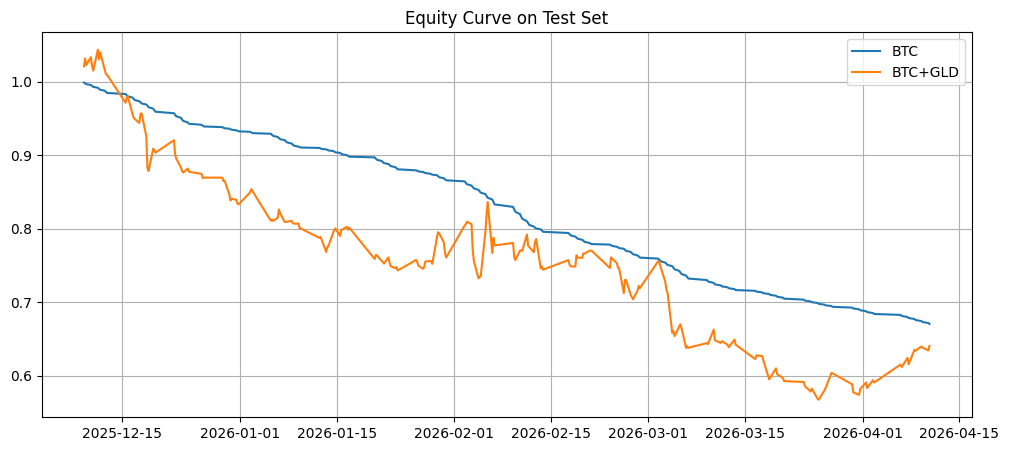

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(results_btc_strategy.index, results_btc_strategy["equity"], label="BTC")
plt.plot(results_btc_gld_strategy.index, results_btc_gld_strategy["equity"], label="BTC+GLD")
plt.title("Equity Curve on Test Set")
plt.legend()
plt.grid(True)
plt.show()

Comparació contra buy-and-hold

In [34]:
buy_hold_ret = test_btc["btc_close"].iloc[-1] / test_btc["btc_close"].iloc[0] - 1
print("Buy & Hold return:", buy_hold_ret)

Buy & Hold return: -0.19289039928811869


Veure accions dels dos models per separat

In [35]:
print("BTC actions:")
print(results_btc_strategy["action"].value_counts())

print("\nBTC+GLD actions:")
print(results_btc_gld_strategy["action"].value_counts())

print("\nBTC positions:")
print(results_btc_strategy["position"].value_counts())

print("\nBTC+GLD positions:")
print(results_btc_gld_strategy["position"].value_counts())

BTC actions:
action
0    227
Name: count, dtype: int64

BTC+GLD actions:
action
1    227
Name: count, dtype: int64

BTC positions:
position
0    227
Name: count, dtype: int64

BTC+GLD positions:
position
-1    116
 1    111
Name: count, dtype: int64
